# GDELT Big Data Project

**Local run** — no Google Drive. Set `BASE_DIR` to the folder where your `daily/` parquet files live.

In [1]:
import os

# ── CHANGE THIS to wherever your daily parquet files are ──────────────────────
BASE_DIR      = r"D:/Projects/gdelt_data"   # Windows example
# BASE_DIR    = "/Users/yourname/gdelt_data"       # Mac/Linux example
# ─────────────────────────────────────────────────────────────────────────────

DAILY_DIR     = os.path.join(BASE_DIR, "daily")
CLEAN_DIR     = os.path.join(BASE_DIR, "cleaned")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed")
RESULTS_DIR   = os.path.join(BASE_DIR, "results")

for d in (CLEAN_DIR, PROCESSED_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

# Verify data is present before doing anything else
import glob
files = sorted(glob.glob(os.path.join(DAILY_DIR, "*.parquet")))
print(f"Daily files found: {len(files)}")
assert len(files) > 200, (
    f"Only {len(files)} parquet files found in {DAILY_DIR}.\n"
    "Make sure you downloaded and unzipped gdelt_data/daily/ from Google Drive."
)
print("All paths OK.")

Daily files found: 227
All paths OK.


# Spark session

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType, StringType

spark = (
    SparkSession.builder
        .appName("gdelt_pipeline")
        .config("spark.driver.memory", "10g")
        .config("spark.local.dir", "D:/spark_temp")
        .config("spark.sql.shuffle.partitions", "16")   # right-sized for local
        .config("spark.sql.ansi.enabled", "false")      # lenient casts: bad values -> null
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

import pyspark
print(f"PySpark : {pyspark.__version__}")
print(f"Spark   : {spark.version}")
assert pyspark.__version__.split(".")[:2] == spark.version.split(".")[:2], (
    "PySpark and Spark JVM versions do not match — reinstall pyspark to match your JVM."
)
print("Versions match.")

PySpark : 4.1.1
Spark   : 4.1.1
Versions match.


# Data preprocessing

Reads all daily parquet files from local disk. Every column is a string (written by the corrected scraper). Numeric columns are cast explicitly below.

In [3]:
sdf_raw = spark.read.parquet(DAILY_DIR + "/")
n_before = sdf_raw.count()
print(f"Total rows loaded : {n_before:,}")
print(f"Partitions        : {sdf_raw.rdd.getNumPartitions()}")
sdf_raw.select(F.min("SQLDATE"), F.max("SQLDATE"),
               F.min("DATEADDED"), F.max("DATEADDED")).show()

Total rows loaded : 24,457,373
Partitions        : 22
+------------+------------+--------------+--------------+
|min(SQLDATE)|max(SQLDATE)|min(DATEADDED)|max(DATEADDED)|
+------------+------------+--------------+--------------+
|    20151004|    20260515|20251001000000|20260515234500|
+------------+------------+--------------+--------------+



In [4]:
# --- Parse dates ---
sdf = (sdf_raw
    .withColumn("date",       F.to_date(F.col("SQLDATE"), "yyyyMMdd"))
    .withColumn("date_added", F.to_date(F.substring(F.col("DATEADDED"), 1, 8), "yyyyMMdd"))
)

# --- Cheap filters first (shrinks data before the expensive dedup shuffle) ---
sdf = sdf.dropna(subset=["date"])
sdf = sdf.filter(F.col("ActionGeo_CountryCode").isNotNull() &
                 (F.col("ActionGeo_CountryCode") != ""))

# --- Dedup (runs on fewer rows after filtering) ---
sdf = sdf.dropDuplicates(["GLOBALEVENTID"])

# --- Cast numeric columns (ansi.enabled=false means junk values -> null) ---
numeric_cols = [
    "GoldsteinScale", "AvgTone", "NumMentions", "NumSources", "NumArticles",
    "QuadClass", "EventCode", "EventRootCode", "EventBaseCode",
    "IsRootEvent", "GLOBALEVENTID",
    "ActionGeo_Lat", "ActionGeo_Long",
    "Actor1Geo_Lat", "Actor1Geo_Long",
    "Actor2Geo_Lat", "Actor2Geo_Long",
]
for c in numeric_cols:
    if c in sdf.columns:
        sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))

# --- Goldstein range filter ---
sdf = sdf.filter(F.col("GoldsteinScale").isNull() |
                 F.col("GoldsteinScale").between(-10, 10))

# --- Time buckets ---
sdf = (sdf
    .withColumn("year",  F.year("date"))
    .withColumn("month", F.trunc("date", "month"))
    .withColumn("week",  F.date_trunc("week", F.col("date").cast("timestamp")).cast("date"))
)

n_after = sdf.count()
print(f"Rows before : {n_before:,}")
print(f"Rows after  : {n_after:,}")
print(f"Dropped     : {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.1f}%)")

Rows before : 24,457,373
Rows after  : 23,787,531
Dropped     : 669,842 (2.7%)


In [5]:
sdf.select(
    F.min("date").alias("min_date"),
    F.max("date").alias("max_date"),
    F.countDistinct("date").alias("unique_days"),
    F.countDistinct("month").alias("unique_months"),
    F.countDistinct("ActionGeo_CountryCode").alias("n_countries"),
).show()

corr_full = sdf.stat.corr("GoldsteinScale", "AvgTone")
print(f"Goldstein-AvgTone correlation: {corr_full:.3f}")

+----------+----------+-----------+-------------+-----------+
|  min_date|  max_date|unique_days|unique_months|n_countries|
+----------+----------+-----------+-------------+-----------+
|2015-10-04|2026-05-15|        711|           25|        257|
+----------+----------+-----------+-------------+-----------+

Goldstein-AvgTone correlation: 0.337


In [6]:
out_path = os.path.join(CLEAN_DIR, "events_cleaned.parquet")
(sdf.write
    .mode("overwrite")
    .option("compression", "snappy")
    .parquet(out_path))
print(f"Saved: {out_path}")
print(f"Rows : {sdf.count():,}")

Saved: D:/Projects/gdelt_data\cleaned\events_cleaned.parquet
Rows : 23,787,531


# EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]    = 100

CLEAN_PATH = os.path.join(CLEAN_DIR, "events_cleaned.parquet")
sdf = spark.read.parquet(CLEAN_PATH)
sdf.cache()
print(f"Loaded {sdf.count():,} events")
sdf.select(F.min("date"), F.max("date"),
           F.countDistinct("ActionGeo_CountryCode").alias("n_countries")).show()

Loaded 23,787,531 events
+----------+----------+-----------+
| min(date)| max(date)|n_countries|
+----------+----------+-----------+
|2015-10-04|2026-05-15|        257|
+----------+----------+-----------+



Mean events/day   : 33456
Median events/day : 832
Max               : 146,012 on 2026-03-05
Min               : 2 on 2015-12-31


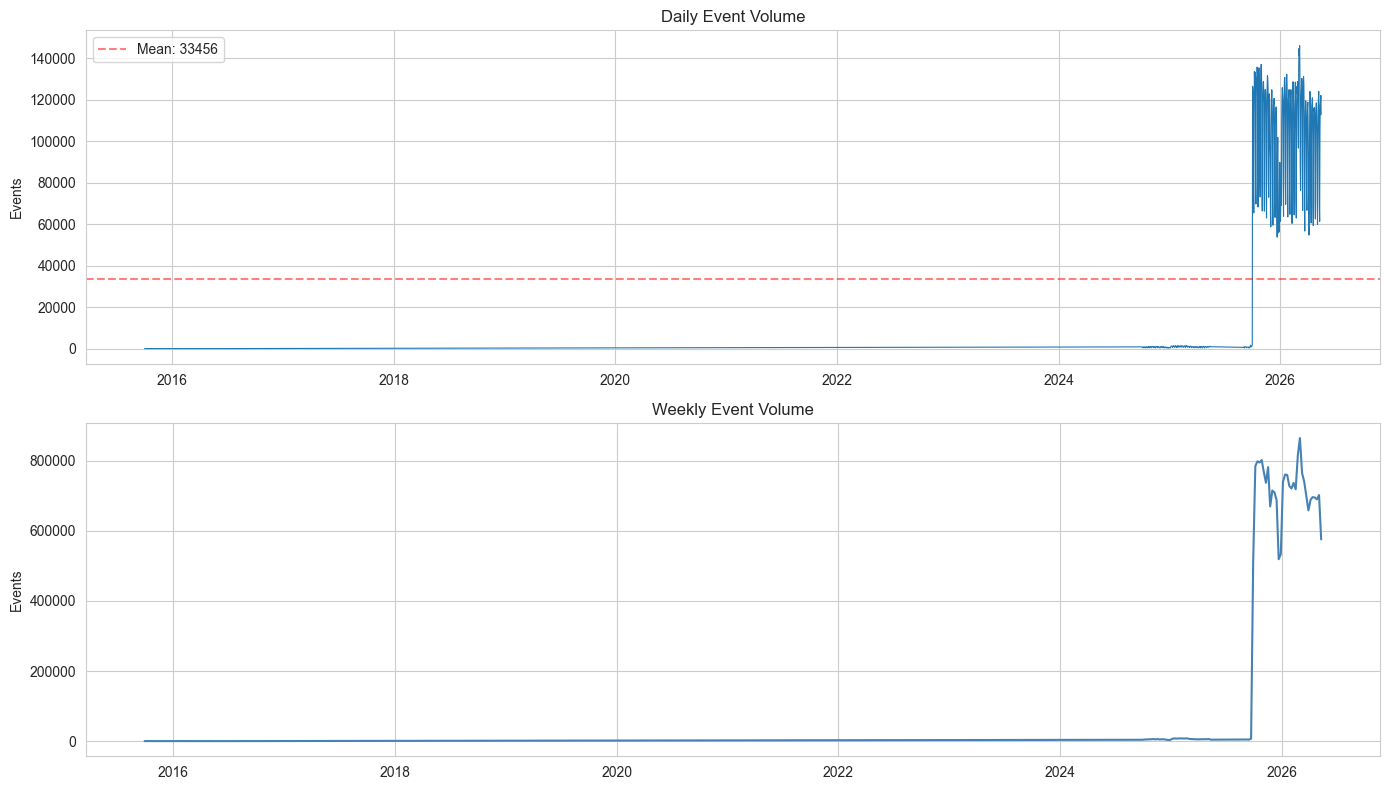

In [8]:
# Daily and weekly volume
daily = (sdf.groupBy("date").count().orderBy("date")
            .toPandas().set_index("date")["count"])

print(f"Mean events/day   : {daily.mean():.0f}")
print(f"Median events/day : {daily.median():.0f}")
print(f"Max               : {daily.max():,} on {daily.idxmax()}")
print(f"Min               : {daily.min():,} on {daily.idxmin()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].axhline(daily.mean(), color="red", linestyle="--", alpha=0.5,
                label=f"Mean: {daily.mean():.0f}")
axes[0].set_title("Daily Event Volume"); axes[0].set_ylabel("Events"); axes[0].legend()

weekly = (sdf.groupBy("week").count().orderBy("week")
             .toPandas().set_index("week")["count"])
axes[1].plot(weekly.index, weekly.values, linewidth=1.5, color="steelblue")
axes[1].set_title("Weekly Event Volume"); axes[1].set_ylabel("Events")
plt.tight_layout(); plt.show()

Total countries: 257
Countries >=100 events: 241


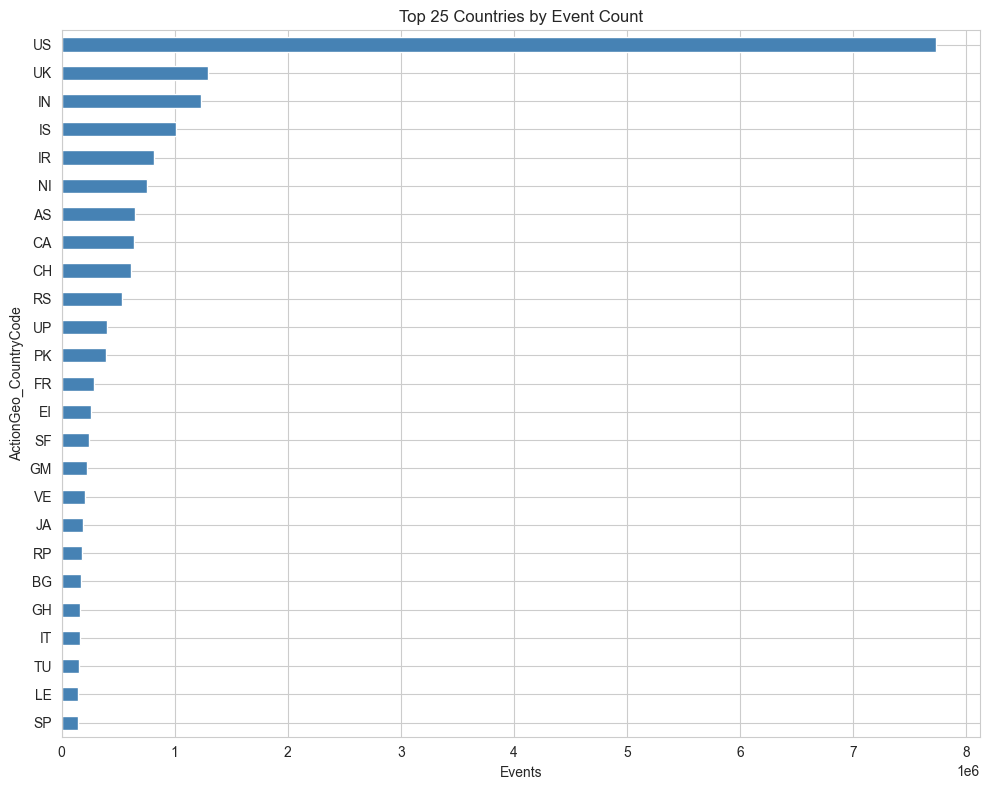

Top 10 countries: 64.2% of events


In [9]:
# Country event counts
country_counts = (sdf.groupBy("ActionGeo_CountryCode").count()
                     .toPandas().set_index("ActionGeo_CountryCode")["count"]
                     .sort_values(ascending=False))
print(f"Total countries: {len(country_counts)}")
print(f"Countries >=100 events: {(country_counts >= 100).sum()}")

fig, ax = plt.subplots(figsize=(10, 8))
country_counts.head(25).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 25 Countries by Event Count"); ax.set_xlabel("Events")
plt.tight_layout(); plt.show()
print(f"Top 10 countries: {country_counts.head(10).sum()/country_counts.sum()*100:.1f}% of events")

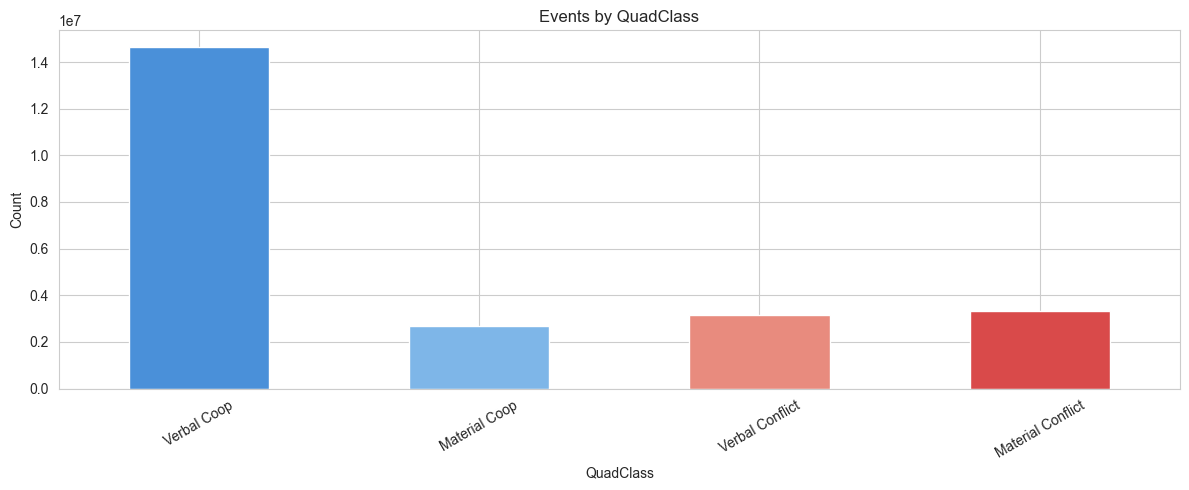

In [10]:
# QuadClass distribution
quad_labels = {1:"Verbal Coop", 2:"Material Coop", 3:"Verbal Conflict", 4:"Material Conflict"}
quad_counts = (sdf.groupBy("QuadClass").count().orderBy("QuadClass")
                  .toPandas().dropna().set_index("QuadClass")["count"])
quad_counts.rename(index=quad_labels).plot(
    kind="bar", color=["#4a90d9","#7eb6e8","#e88b7e","#d94a4a"])
plt.title("Events by QuadClass"); plt.ylabel("Count")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

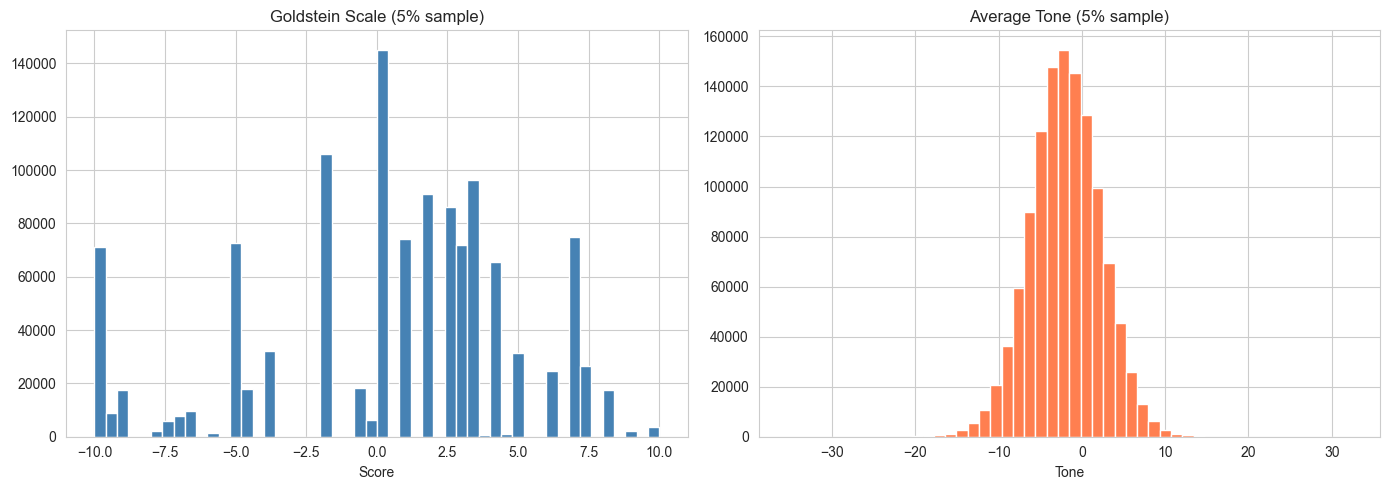

In [11]:
# Goldstein + AvgTone distributions
sample_pdf = (sdf.select("GoldsteinScale", "AvgTone")
                 .dropna().sample(fraction=0.05, seed=42).toPandas())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sample_pdf["GoldsteinScale"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Goldstein Scale (5% sample)"); axes[0].set_xlabel("Score")
axes[1].hist(sample_pdf["AvgTone"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Average Tone (5% sample)"); axes[1].set_xlabel("Tone")
plt.tight_layout(); plt.show()

In [12]:
# Country-level intensity
country_intensity = (sdf.groupBy("ActionGeo_CountryCode")
    .agg(
        F.count("GLOBALEVENTID").alias("n_events"),
        F.mean("GoldsteinScale").alias("goldstein_mean"),
        F.stddev("GoldsteinScale").alias("goldstein_std"),
        F.mean("AvgTone").alias("tone_mean"),
        F.mean("NumMentions").alias("mentions_mean"),
    ).orderBy(F.desc("n_events")).toPandas())

country_quad = (sdf.groupBy("ActionGeo_CountryCode")
    .pivot("QuadClass", [1,2,3,4]).count().fillna(0).toPandas())

country_intensity.to_csv(os.path.join(PROCESSED_DIR, "eda_country_intensity.csv"), index=False)
country_quad.to_csv(os.path.join(PROCESSED_DIR, "eda_country_quad.csv"), index=False)
print(f"Saved EDA outputs to {PROCESSED_DIR}")
print(country_intensity.head(10).to_string(index=False))

Saved EDA outputs to D:/Projects/gdelt_data\processed
ActionGeo_CountryCode  n_events  goldstein_mean  goldstein_std  tone_mean  mentions_mean
                   US   7733879        0.431672       4.666073  -2.177676       4.426337
                   UK   1291266        0.707337       4.338976  -1.465647       5.033655
                   IN   1230996        0.703790       4.371213  -1.349118       4.970068
                   IS   1012031       -0.722678       5.375808  -3.993253       3.924162
                   IR    819421       -0.691450       5.277199  -4.045146       4.125485
                   NI    751814        0.086137       4.617945  -1.913359       4.330446
                   AS    645271        0.557485       4.461173  -1.772580       5.864265
                   CA    635547        1.017984       4.334773  -0.726146       5.083473
                   CH    613435        1.254290       4.136133  -0.727897       4.561662
                   RS    533588        0.051375       5.

# Feature engineering — country-month panel

In [13]:
CLEAN_PATH = os.path.join(CLEAN_DIR, "events_cleaned.parquet")
sdf = spark.read.parquet(CLEAN_PATH)
print(f"Loaded {sdf.count():,} events")

MIN_EVENTS_PER_BUCKET = 5

# Core aggregates per country-month
agg = (sdf
    .withColumnRenamed("ActionGeo_CountryCode", "country")
    .withColumnRenamed("month", "period")
    .groupBy("country", "period")
    .agg(
        F.count("GLOBALEVENTID").alias("n_events"),
        F.mean("GoldsteinScale").alias("goldstein_mean"),
        F.stddev("GoldsteinScale").alias("goldstein_std"),
        F.min("GoldsteinScale").alias("goldstein_min"),
        F.mean("AvgTone").alias("tone_mean"),
        F.stddev("AvgTone").alias("tone_std"),
        F.sum("NumMentions").alias("mentions_sum"),
        F.mean("NumMentions").alias("mentions_mean"),
        F.mean("NumSources").alias("sources_mean"),
        F.countDistinct("Actor1CountryCode").alias("n_unique_actor1"),
        F.countDistinct("Actor2CountryCode").alias("n_unique_actor2"),
    ))

# QuadClass pivot
quad = (sdf
    .withColumnRenamed("ActionGeo_CountryCode", "country")
    .withColumnRenamed("month", "period")
    .groupBy("country", "period")
    .pivot("QuadClass", [1, 2, 3, 4]).count().fillna(0))
for q in [1, 2, 3, 4]:
    quad = quad.withColumnRenamed(str(q), f"quad_{q}_count")

# Merge + derived ratios
panel_sdf = (agg.join(quad, ["country", "period"], "left")
    .fillna(0, subset=[f"quad_{q}_count" for q in [1,2,3,4]])
    .withColumn("verbal_coop_ratio",       F.col("quad_1_count") / F.col("n_events"))
    .withColumn("material_coop_ratio",     F.col("quad_2_count") / F.col("n_events"))
    .withColumn("verbal_conflict_ratio",   F.col("quad_3_count") / F.col("n_events"))
    .withColumn("material_conflict_ratio", F.col("quad_4_count") / F.col("n_events"))
    .withColumn("any_conflict_ratio",
                (F.col("quad_3_count") + F.col("quad_4_count")) / F.col("n_events"))
    .filter(F.col("n_events") >= MIN_EVENTS_PER_BUCKET)
    .fillna(0, subset=["goldstein_std", "tone_std"]))

print(f"Panel rows        : {panel_sdf.count():,}")
print(f"Unique countries  : {panel_sdf.select('country').distinct().count()}")
print(f"Unique periods    : {panel_sdf.select('period').distinct().count()}")

Loaded 23,787,531 events
Panel rows        : 3,550
Unique countries  : 249
Unique periods    : 25


In [14]:
# Define current-month label then shift forward one month (forecasting target)
mcr_median = panel_sdf.approxQuantile("material_conflict_ratio", [0.5], 0.0)[0]
print(f"Median material_conflict_ratio: {mcr_median:.4f}")

panel_sdf = panel_sdf.withColumn(
    "unstable_now",
    ((F.col("goldstein_mean") < 0) &
     (F.col("material_conflict_ratio") > F.lit(mcr_median))).cast("int")
)

# Lead window: t+1 instability on each row t, per country
w = Window.partitionBy("country").orderBy("period")
panel_sdf = panel_sdf.withColumn("unstable_next", F.lead("unstable_now", 1).over(w))

# Drop last period per country (no next month exists)
panel_fc = panel_sdf.filter(F.col("unstable_next").isNotNull())

print(f"Rows with a next-month label: {panel_fc.count():,}")
panel_fc.groupBy("unstable_next").count().orderBy("unstable_next").show()

panel_sdf.write.mode("overwrite").parquet(os.path.join(PROCESSED_DIR, "panel_country_month.parquet"))
panel_fc.write.mode("overwrite").parquet(os.path.join(PROCESSED_DIR, "panel_forecast.parquet"))
print("Saved panel_country_month.parquet and panel_forecast.parquet")

Median material_conflict_ratio: 0.1096
Rows with a next-month label: 3,301
+-------------+-----+
|unstable_next|count|
+-------------+-----+
|            0| 2686|
|            1|  615|
+-------------+-----+

Saved panel_country_month.parquet and panel_forecast.parquet


In [ ]:

panel = spark.read.parquet(os.path.join(PROCESSED_DIR, "panel_forecast.parquet")).toPandas()
print(f"Forecasting panel : {len(panel):,} rows")
print(f"Positive rate     : {panel['unstable_next'].mean():.1%}")
panel.head()

Forecasting panel : 3,301 rows
Positive rate     : 18.6%


,country,period,n_events,goldstein_mean,goldstein_std,goldstein_min,tone_mean,tone_std,mentions_sum,mentions_mean,...,quad_2_count,quad_3_count,quad_4_count,verbal_coop_ratio,material_coop_ratio,verbal_conflict_ratio,material_conflict_ratio,any_conflict_ratio,unstable_now,unstable_next
0,AA,2025-10-01,201,1.692040,3.453120,-10.0,-0.337183,4.566237,894.0,4.447761,...,31,9,12,0.741294,0.154229,0.044776,0.059701,0.104478,0,0
1,AA,2025-11-01,219,2.081279,3.243592,-10.0,1.474716,3.588366,1009.0,4.607306,...,19,14,5,0.826484,0.086758,0.063927,0.022831,0.086758,0,0
2,AA,2025-12-01,276,1.328261,3.630847,-10.0,-1.244297,4.721771,1703.0,6.170290,...,23,23,20,0.760870,0.083333,0.083333,0.072464,0.155797,0,0
3,AA,2026-01-01,327,1.145260,3.631268,-10.0,-1.615813,3.007061,1876.0,5.737003,...,31,15,51,0.703364,0.094801,0.045872,0.155963,0.201835,0,0
4,AA,2026-02-01,206,2.770388,3.009359,-5.0,1.924205,4.227165,1467.0,7.121359,...,32,10,4,0.776699,0.155340,0.048544,0.019417,0.067961,0,0


# Shared features (leakage-safe)

`LABEL_INPUTS` = columns used to build the label → **excluded from features**.  
`FEATURE_COLS` = signals from month *t* used to predict instability at *t+1*.

In [16]:
import numpy as np

# Columns the label is derived from — must NOT appear as features
LABEL_INPUTS = [
    "material_conflict_ratio", "goldstein_mean",
    "verbal_conflict_ratio", "any_conflict_ratio",
    "quad_3_count", "quad_4_count",
    "goldstein_min",
    "unstable_now", "unstable_next",
]

FEATURE_COLS = [
    "n_events",
    "goldstein_std",
    "tone_mean",
    "tone_std",
    "mentions_mean",
    "sources_mean",
    "n_unique_actor1",
    "n_unique_actor2",
    "verbal_coop_ratio",
    "material_coop_ratio",
]

# Leakage guard — fails loudly if any feature is also a label input
overlap = set(FEATURE_COLS) & set(LABEL_INPUTS)
assert not overlap, f"LEAKAGE DETECTED: {overlap}"
print(f"{len(FEATURE_COLS)} features, 0 overlap with label inputs. Leakage guard passed.")

X = panel[FEATURE_COLS].copy()
y = panel["unstable_next"].astype(int).values

# Log-transform right-skewed count columns
for c in ["n_events", "mentions_mean", "n_unique_actor1", "n_unique_actor2"]:
    X[c] = np.log1p(X[c])

mask = X.notna().all(axis=1)
X, y = X[mask].reset_index(drop=True), y[mask]
print(f"X shape: {X.shape}  |  positive rate: {y.mean():.3f}")

10 features, 0 overlap with label inputs. Leakage guard passed.
X shape: (3301, 10)  |  positive rate: 0.186


# CLUSTERING

In [25]:
# ── CLUSTERING ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# Scale features (clustering is distance-based, scaling is mandatory)
scaler_cl = StandardScaler()
X_scaled   = scaler_cl.fit_transform(X)

# PCA to 2D for visualization
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}")

PCA variance explained: 54.2%


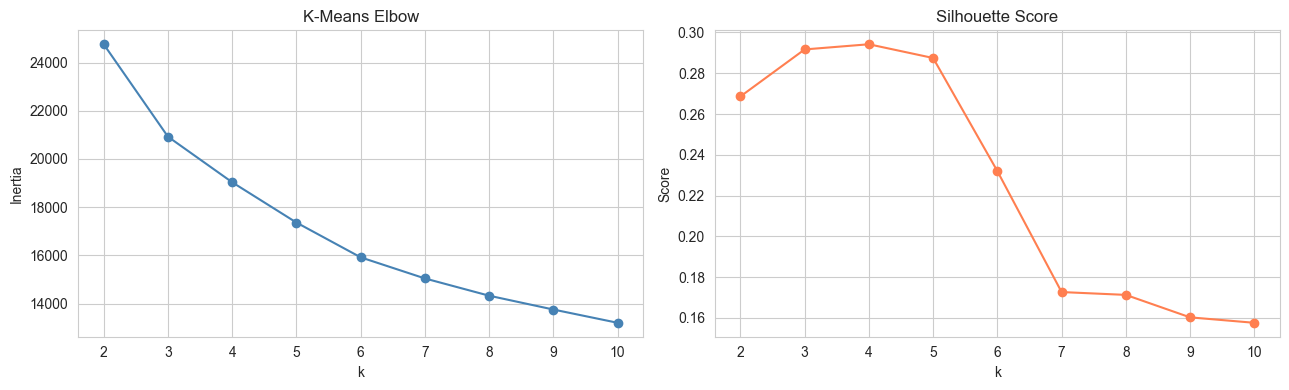

Best k by silhouette: 4  (score=0.294)


In [26]:
# ── K-MEANS ───────────────────────────────────────────────────────────────────

# Elbow + silhouette to pick k
inertias, sil_scores, k_range = [], [], range(2, 11)
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_title("K-Means Elbow"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="coral")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}  (score={max(sil_scores):.3f})")

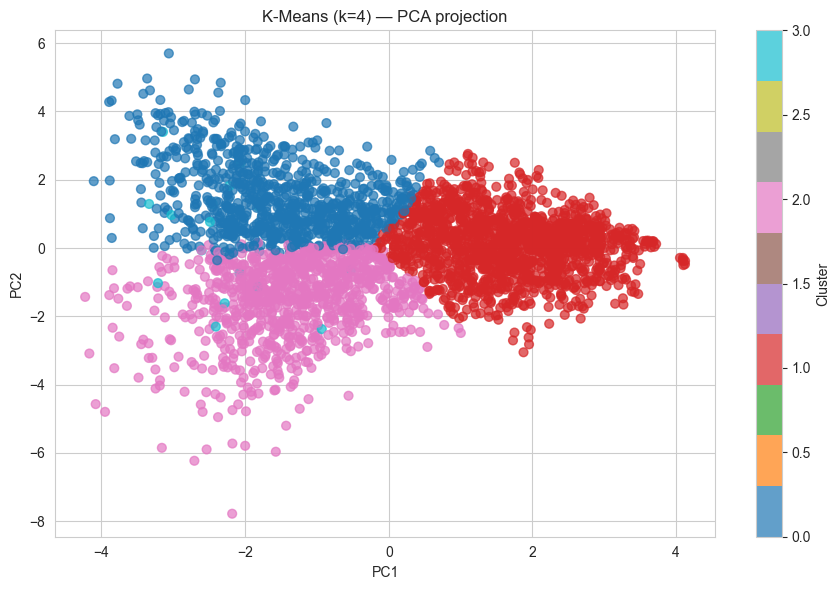


Cluster profiles (feature means):
            n_events  goldstein_std  tone_mean  tone_std  mentions_mean  sources_mean  n_unique_actor1  n_unique_actor2  verbal_coop_ratio  material_coop_ratio  unstable_next
km_cluster                                                                                                                                                                    
0              3.449          3.167     -0.028     2.980          1.695         1.027            1.910            1.845              0.799                0.075          0.141
1              7.901          4.376     -1.349     4.125          1.730         1.035            4.053            3.991              0.656                0.110          0.128
2              3.406          4.894     -2.718     3.490          1.667         1.033            1.908            1.836              0.456                0.179          0.319
3              2.753          3.808     -1.028     2.104          2.068         2.257     

In [27]:
# Fit final K-Means with best k
kmeans      = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels   = kmeans.fit_predict(X_scaled)

panel_cl = X.copy()
panel_cl["km_cluster"]    = km_labels
panel_cl["unstable_next"] = y
panel_cl["pca_1"]         = X_pca[:, 0]
panel_cl["pca_2"]         = X_pca[:, 1]

# PCA scatter
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=km_labels, cmap="tab10", alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title(f"K-Means (k={best_k}) — PCA projection")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

# Cluster profiles
print("\nCluster profiles (feature means):")
profile = (panel_cl.groupby("km_cluster")[FEATURE_COLS + ["unstable_next"]]
           .mean().round(3))
print(profile.to_string())

# Instability rate per cluster
print("\nInstability rate per cluster:")
print(panel_cl.groupby("km_cluster")["unstable_next"]
      .agg(["mean","count"]).rename(columns={"mean":"instability_rate"}).round(3))

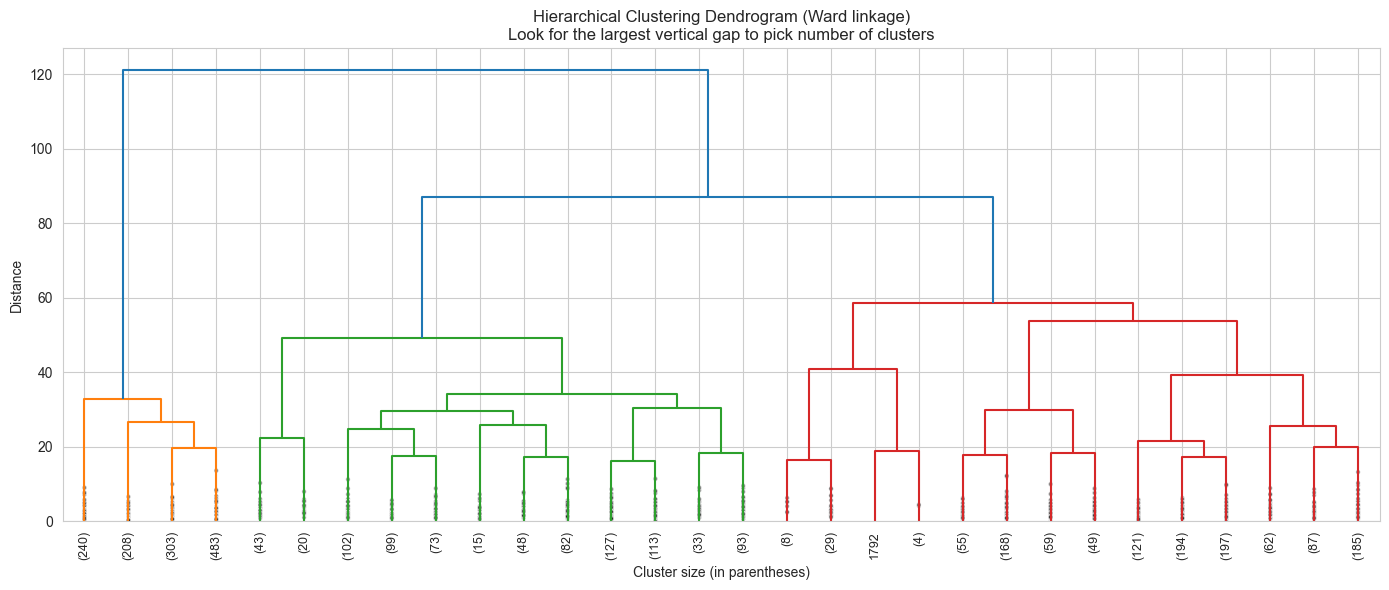

In [32]:
# ── AGGLOMERATIVE (HIERARCHICAL) CLUSTERING ───────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# ── Step 1: Dendrogram to pick number of clusters ────────────────────────────
linked = linkage(X_scaled, method="ward")   # Ward minimizes within-cluster variance

plt.figure(figsize=(14, 6))
dendrogram(linked,
           truncate_mode="lastp",   # show only last p merged clusters
           p=30,                    # show top 30 merges
           leaf_rotation=90,
           leaf_font_size=9,
           show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)\n"
          "Look for the largest vertical gap to pick number of clusters")
plt.xlabel("Cluster size (in parentheses)")
plt.ylabel("Distance")
plt.tight_layout(); plt.show()

In [33]:
# ── Step 2: Fit with chosen number of clusters ────────────────────────────────
# Pick n_clusters where you see the biggest vertical gap in the dendrogram above
N_CLUSTERS = best_k   # start with same k as K-Means for a fair comparison

agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, agg_labels)
print(f"Agglomerative clusters : {N_CLUSTERS}")
print(f"Silhouette score       : {sil:.3f}")

panel_cl["agg_cluster"] = agg_labels

Agglomerative clusters : 4
Silhouette score       : 0.238


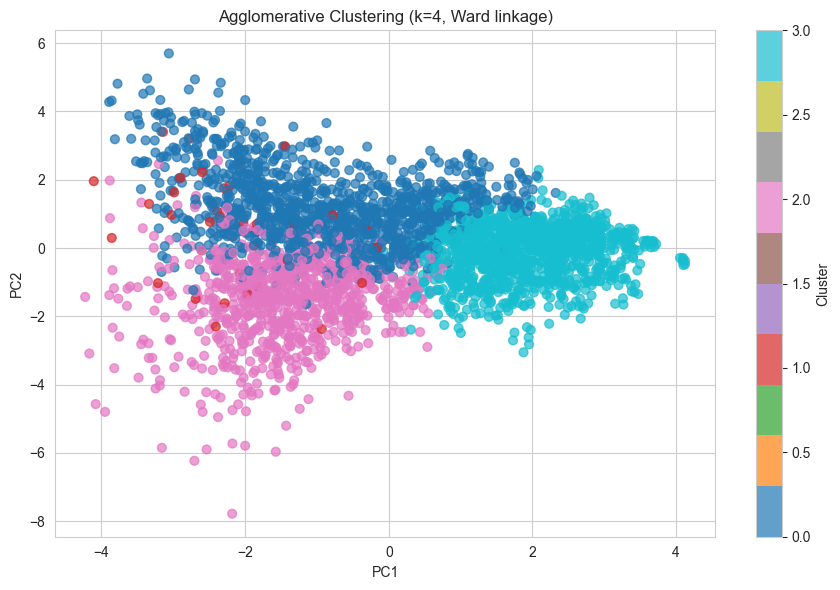

In [34]:
# ── Step 3: PCA visualization ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=agg_labels, cmap="tab10", alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title(f"Agglomerative Clustering (k={N_CLUSTERS}, Ward linkage)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

In [35]:
# ── Step 4: Cluster profiles ──────────────────────────────────────────────────
print("Agglomerative cluster profiles:")
agg_profile = (panel_cl.groupby("agg_cluster")[FEATURE_COLS + ["unstable_next"]]
               .mean().round(3))
print(agg_profile.to_string())

print("\nInstability rate per cluster:")
print(panel_cl.groupby("agg_cluster")["unstable_next"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "instability_rate"})
      .round(3))

Agglomerative cluster profiles:
             n_events  goldstein_std  tone_mean  tone_std  mentions_mean  sources_mean  n_unique_actor1  n_unique_actor2  verbal_coop_ratio  material_coop_ratio  unstable_next
agg_cluster                                                                                                                                                                    
0               4.227          3.476     -0.102     3.345          1.715         1.023            2.307            2.239              0.769                0.081          0.116
1               3.092          3.395     -0.967     2.332          1.936         1.731            1.639            1.588              0.676                0.142          0.262
2               3.291          4.859     -2.721     3.379          1.655         1.028            1.857            1.787              0.451                0.187          0.328
3               8.242          4.490     -1.729     4.155          1.722         1.036  

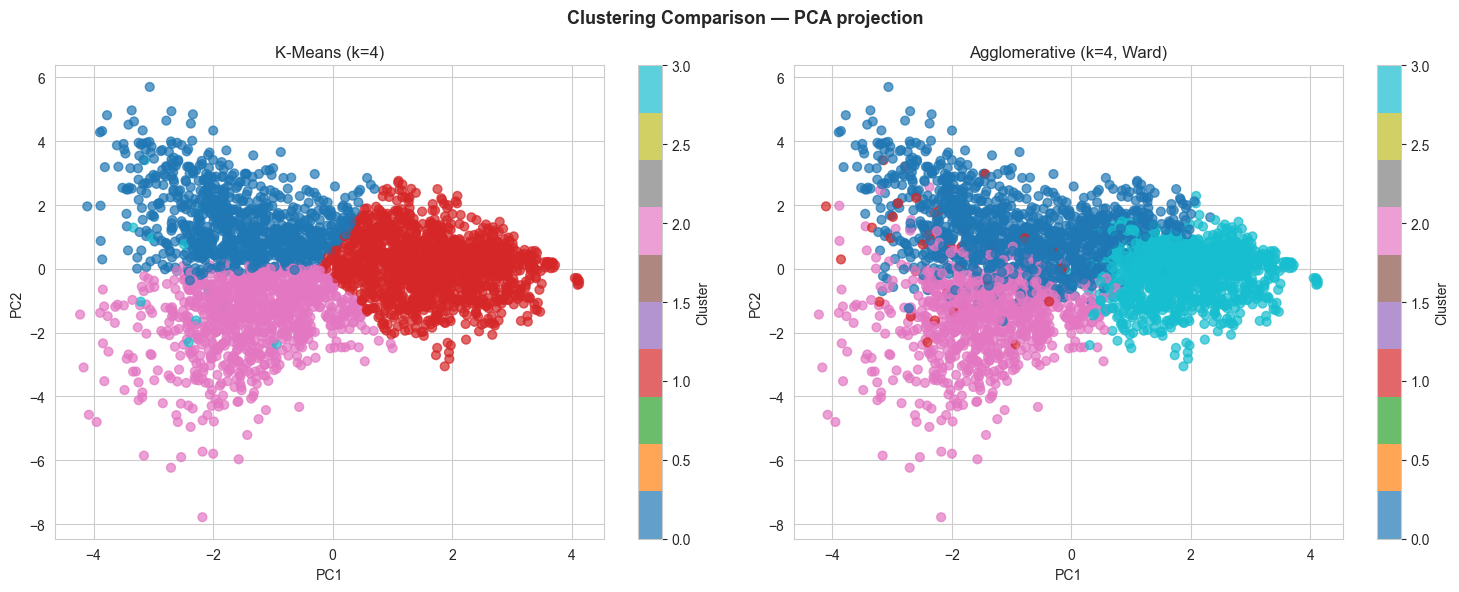


Silhouette scores:
  K-Means        : 0.294
  Agglomerative  : 0.238
  Winner         : K-Means

Saved -> D:/Projects/gdelt_data\processed/clustering_results.csv


In [36]:
# ── Step 5: K-Means vs Agglomerative comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=km_labels, cmap="tab10", alpha=0.7, s=40)
axes[0].set_title(f"K-Means (k={best_k})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Cluster")

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=agg_labels, cmap="tab10", alpha=0.7, s=40)
axes[1].set_title(f"Agglomerative (k={N_CLUSTERS}, Ward)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="Cluster")

plt.suptitle("Clustering Comparison — PCA projection", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Silhouette comparison
km_sil  = silhouette_score(X_scaled, km_labels)
agg_sil = silhouette_score(X_scaled, agg_labels)
print(f"\nSilhouette scores:")
print(f"  K-Means        : {km_sil:.3f}")
print(f"  Agglomerative  : {agg_sil:.3f}")
print(f"  Winner         : {'K-Means' if km_sil > agg_sil else 'Agglomerative'}")

panel_cl.to_csv(os.path.join(PROCESSED_DIR, "clustering_results.csv"), index=False)
print(f"\nSaved -> {PROCESSED_DIR}/clustering_results.csv")

# Model 1 — Logistic Regression

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {X_train.shape}  pos={y_train.mean():.3f}")
print(f"Test : {X_test.shape}   pos={y_test.mean():.3f}")

logreg = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                            max_iter=2000, solver="lbfgs", random_state=42)
logreg.fit(X_train_s, y_train)

y_pred  = logreg.predict(X_test_s)
y_proba = logreg.predict_proba(X_test_s)[:, 1]

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred,
                            target_names=["stable","unstable"], digits=3))
print("=== Confusion matrix ===")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=["actual_stable","actual_unstable"],
                   columns=["pred_stable","pred_unstable"]))
print(f"\nROC-AUC           : {roc_auc_score(y_test, y_proba):.3f}")
print(f"Average precision : {average_precision_score(y_test, y_proba):.3f}")

Train: (2475, 10)  pos=0.186
Test : (826, 10)   pos=0.186

=== Classification report ===
              precision    recall  f1-score   support

      stable      0.913     0.720     0.805       672
    unstable      0.365     0.701     0.480       154

    accuracy                          0.717       826
   macro avg      0.639     0.711     0.643       826
weighted avg      0.811     0.717     0.745       826

=== Confusion matrix ===
                 pred_stable  pred_unstable
actual_stable            484            188
actual_unstable           46            108

ROC-AUC           : 0.777
Average precision : 0.432


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
# 5-fold cross-validated AUC (scaling inside each fold)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                  max_iter=2000, solver="lbfgs", random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC-AUC: {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}")
print(f"Per-fold         : {np.round(auc_scores, 3)}")

5-fold CV ROC-AUC: 0.774 +/- 0.033
Per-fold         : [0.763 0.754 0.828 0.79  0.734]


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

            feature  coefficient  odds_ratio
           n_events        0.746       2.109
    n_unique_actor1       -0.703       0.495
          tone_mean       -0.662       0.516
    n_unique_actor2       -0.418       0.658
      goldstein_std        0.302       1.353
      mentions_mean       -0.289       0.749
       sources_mean        0.146       1.158
  verbal_coop_ratio       -0.145       0.865
material_coop_ratio       -0.117       0.890
           tone_std       -0.094       0.910


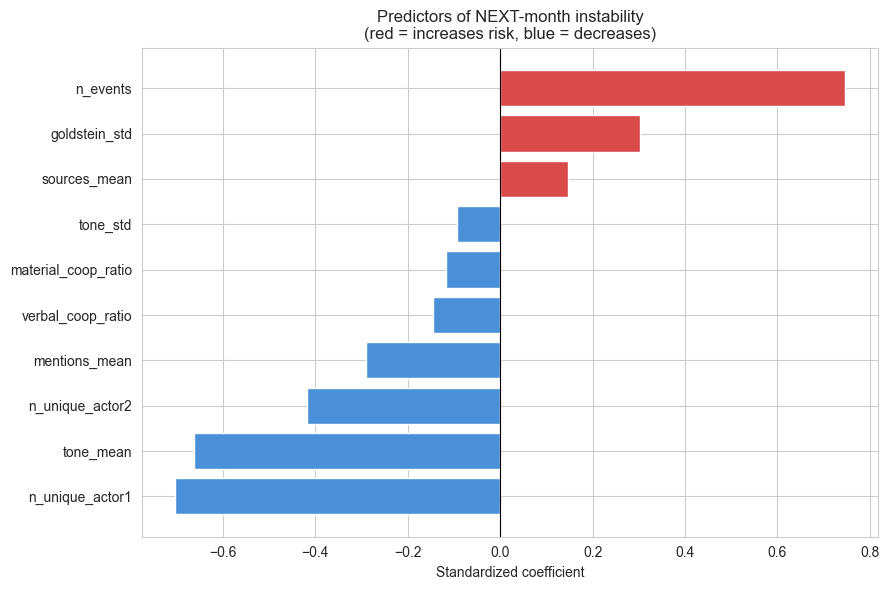

Saved -> D:/Projects/gdelt_data\processed/logreg_coefficients.csv


In [19]:
# Coefficients
coef_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "coefficient": logreg.coef_[0],
    "odds_ratio":  np.exp(logreg.coef_[0]),
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ordered = coef_df.sort_values("coefficient")
colors  = ["#d94a4a" if c > 0 else "#4a90d9" for c in ordered["coefficient"]]
ax.barh(ordered["feature"], ordered["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Predictors of NEXT-month instability\n(red = increases risk, blue = decreases)")
plt.tight_layout(); plt.show()

coef_df.to_csv(os.path.join(PROCESSED_DIR, "logreg_coefficients.csv"), index=False)
print(f"Saved -> {PROCESSED_DIR}/logreg_coefficients.csv")

# Model 2 — XGBoost (same target, same features)

Identical forecasting target and leakage-safe feature set — scores are directly comparable to logistic regression.

In [21]:
import xgboost as xgb
import shap, joblib
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight = {spw:.3f}")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=0)

model = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, early_stopping_rounds=20,
    eval_metric="logloss", random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=50)
print(f"\nBest iteration: {model.best_iteration}")

scale_pos_weight = 4.369
[0]	validation_0-logloss:0.67775
[50]	validation_0-logloss:0.50835
[100]	validation_0-logloss:0.49469
[150]	validation_0-logloss:0.48650
[200]	validation_0-logloss:0.48055
[250]	validation_0-logloss:0.47472
[300]	validation_0-logloss:0.47136
[349]	validation_0-logloss:0.47147

Best iteration: 329


=== Classification Report ===
              precision    recall  f1-score   support

      Stable      0.874     0.802     0.836       672
    Unstable      0.364     0.494     0.419       154

    accuracy                          0.745       826
   macro avg      0.619     0.648     0.628       826
weighted avg      0.779     0.745     0.758       826

ROC-AUC (test): 0.767
ROC-AUC (5-CV): 0.795 +/- 0.012


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


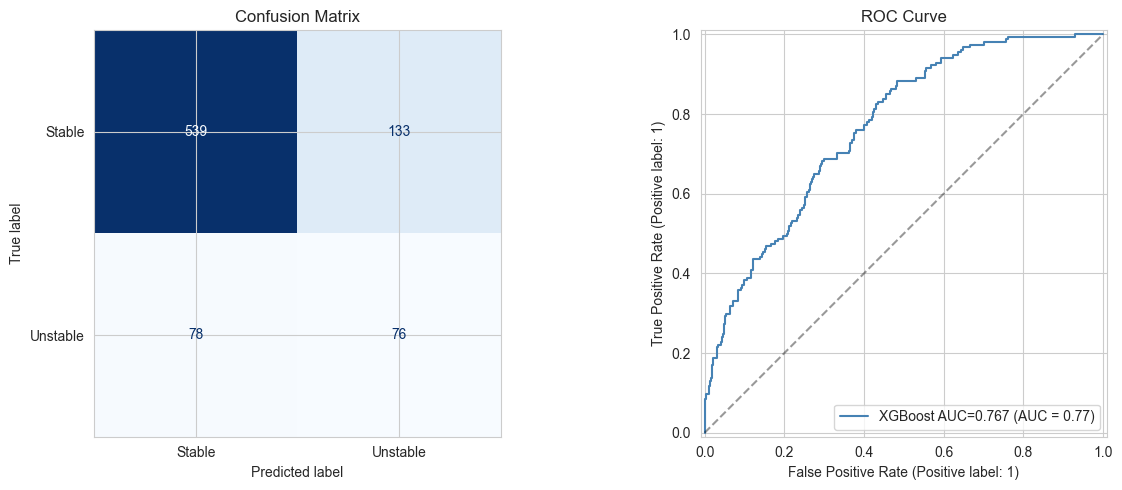

In [22]:
y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                            target_names=["Stable","Unstable"], digits=3))
print(f"ROC-AUC (test): {roc_auc:.3f}")

cv_model = xgb.XGBClassifier(
    n_estimators=max(model.best_iteration, 1), max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    eval_metric="logloss", random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"ROC-AUC (5-CV): {cv_aucs.mean():.3f} +/- {cv_aucs.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=["Stable","Unstable"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_prob,
    name=f"XGBoost AUC={roc_auc:.3f}", ax=axes[1], color="steelblue")
axes[1].plot([0,1],[0,1],"k--",alpha=0.4); axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "xgb_evaluation.png"), bbox_inches="tight")
plt.show()

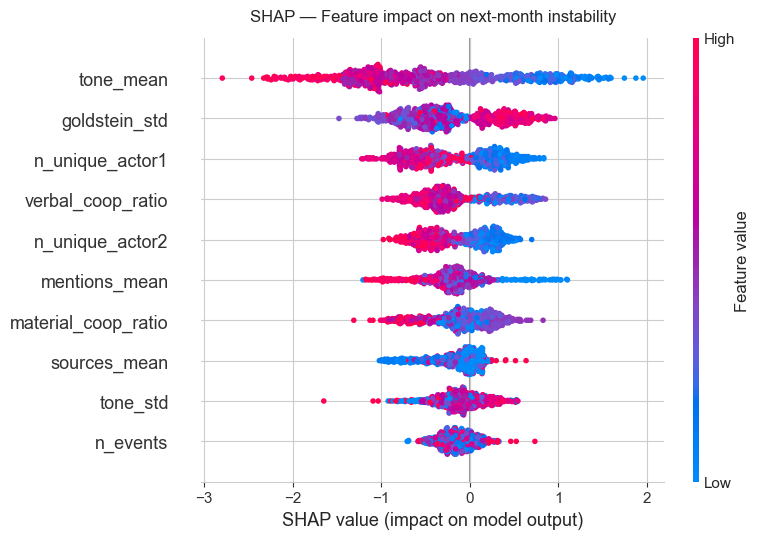

               feature  mean_abs_shap
0            tone_mean       0.870519
1        goldstein_std       0.476990
2      n_unique_actor1       0.428553
3    verbal_coop_ratio       0.388104
4      n_unique_actor2       0.341335
5        mentions_mean       0.285486
6  material_coop_ratio       0.276565
7         sources_mean       0.220516
8             tone_std       0.215069
9             n_events       0.189649


In [23]:
# SHAP feature importance
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP — Feature impact on next-month instability", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_beeswarm.png"), bbox_inches="tight")
plt.show()

shap_df = (pd.DataFrame({
    "feature":        FEATURE_COLS,
    "mean_abs_shap":  np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
print(shap_df.to_string())
shap_df.to_csv(os.path.join(RESULTS_DIR, "shap_importance.csv"), index=False)

In [24]:
# Save model and predictions
joblib.dump(model, os.path.join(RESULTS_DIR, "xgb_model.pkl"))

results_df = X_test.copy().reset_index(drop=True)
results_df["true_next_unstable"] = y_test
results_df["pred_next_unstable"] = y_pred
results_df["prob_next_unstable"] = y_prob
results_df.to_csv(os.path.join(RESULTS_DIR, "xgb_predictions.csv"), index=False)

print("=== Final comparison (same target, same features) ===")
print(f"LogReg  CV ROC-AUC : {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}")
print(f"XGBoost CV ROC-AUC : {cv_aucs.mean():.3f} +/- {cv_aucs.std():.3f}")
print(f"XGBoost test AUC   : {roc_auc:.3f}")
print(f"Saved model + predictions to {RESULTS_DIR}/")

=== Final comparison (same target, same features) ===
LogReg  CV ROC-AUC : 0.774 +/- 0.033
XGBoost CV ROC-AUC : 0.795 +/- 0.012
XGBoost test AUC   : 0.767
Saved model + predictions to D:/Projects/gdelt_data\results/
